## Fruits-360 3-body problem — 품종(variety) 단위 분류 (Transfer Learning)
### 농작물 병해 이미지 탐지 사례
- **TensorFlow 2.10** 기준
- 데이터: `fruits-360-3-body-problem.zip` (Training / Test에 **서로 다른 품종**)
- 상위 3클래스(Apple / Cherry / Tomatoe)가 아닌 **하위 품종 폴더 전체**를 클래스로 사용 (총 64품종)
- 전이학습: **MobileNetV2** (ImageNet 사전학습)

> 이 데이터셋은 Train·Test 품종이 겹치지 않으므로, Test 정확도는 “학습에 없던 품종에 대한 일반화” 성능을 의미합니다.

In [1]:
import os
import json
import zipfile
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import mobilenet_v2

print('TensorFlow:', tf.__version__)
# assert tf.__version__.startswith('2.10'), 'TF 2.10 가상환경(.venv) 커널을 선택하세요.'
print('GPU:', tf.config.list_physical_devices('GPU'))

# 재현성
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 경로 (노트북과 같은 폴더 기준)
ROOT = Path('.').resolve()
ZIP_PATH = ROOT / 'fruits-360-3-body-problem.zip'
DATA_DIR = ROOT / 'fruits-360-3-body-problem'
TRAIN_DIR = DATA_DIR / 'Training'
TEST_DIR = DATA_DIR / 'Test'

IMG_SIZE = 224          # MobileNetV2 입력
BATCH_SIZE = 32
EPOCHS = 15             # 필요 시 조정
FINE_TUNE_AT = 100      # 상위 레이어 미세조정 시작 epoch
VALIDATION_SPLIT = 0.15
AUTOTUNE = tf.data.AUTOTUNE

TensorFlow: 2.10.0
GPU: []


## 1. 데이터셋 압축 해제

In [3]:
def extract_dataset(zip_path: Path, dest_dir: Path) -> None:
    if not zip_path.exists():
        raise FileNotFoundError(f'zip 파일이 없습니다: {zip_path}')
    marker = dest_dir / 'README.md'
    if marker.exists():
        print(f'이미 압축 해제됨: {dest_dir}')
        return
    print(f'압축 해제 중: {zip_path} -> {dest_dir}')
    dest_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall(dest_dir)
    print('압축 해제 완료')

extract_dataset(ZIP_PATH, DATA_DIR)
assert TRAIN_DIR.is_dir() and TEST_DIR.is_dir(), 'Training/Test 폴더를 확인하세요.'

압축 해제 중: C:\MyCursorLab\04_딥러닝_CNN\fruits-360-3-body-problem.zip -> C:\MyCursorLab\04_딥러닝_CNN\fruits-360-3-body-problem
압축 해제 완료


## 2. 품종(variety) 클래스 스캔 및 라벨 맵

In [4]:
IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp'}


def variety_key(split_dir: Path, img_path: Path) -> str:
    """예: Apple/Apple Braeburn 1"""
    rel = img_path.relative_to(split_dir)
    return f'{rel.parts[0]}/{rel.parts[1]}'


def scan_split(split_dir: Path):
    paths, keys = [], []
    for p in split_dir.rglob('*'):
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            paths.append(str(p))
            keys.append(variety_key(split_dir, p))
    return paths, keys


train_paths, train_keys = scan_split(TRAIN_DIR)
test_paths, test_keys = scan_split(TEST_DIR)

all_keys = sorted(set(train_keys) | set(test_keys))
class_to_idx = {k: i for i, k in enumerate(all_keys)}
idx_to_class = {i: k for k, i in class_to_idx.items()}
NUM_CLASSES = len(all_keys)

train_labels = [class_to_idx[k] for k in train_keys]
test_labels = [class_to_idx[k] for k in test_keys]

print(f'전체 품종 클래스 수: {NUM_CLASSES}')
print(f'Training 이미지: {len(train_paths):,} (품종 {len(set(train_keys))}개)')
print(f'Test 이미지: {len(test_paths):,} (품종 {len(set(test_keys))}개)')
print(f'Train/Test 품종 교집합: {len(set(train_keys) & set(test_keys))}개 (0이 정상)')

전체 품종 클래스 수: 64
Training 이미지: 34,800 (품종 48개)
Test 이미지: 12,233 (품종 16개)
Train/Test 품종 교집합: 0개 (0이 정상)


## 3. EDA (탐색적 데이터 분석)

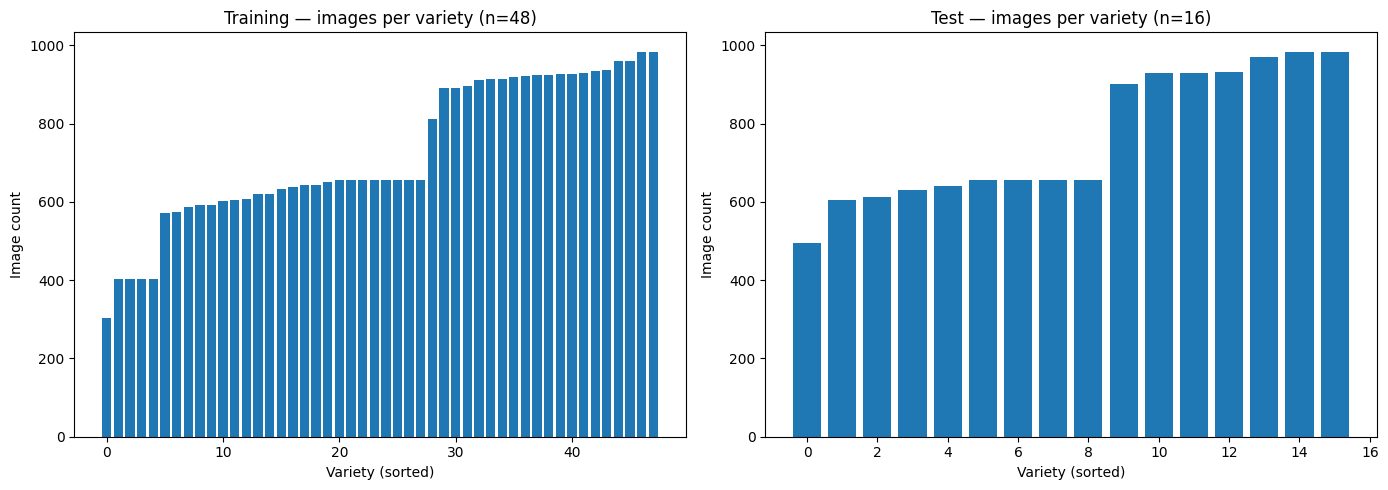

Training — Top 10 varieties by count:
  Cherry/Cherry 2: 984
  Tomatoe/Tomato 3: 984
  Tomatoe/Tomato 8: 961
  Tomatoe/Tomato 9: 959
  Apple/Apple hit 1: 936
  Apple/Apple 13: 934
  Cherry/Cherry 4: 930
  Apple/Apple worm 1: 927
  Cherry/Cherry Rainier 2: 927
  Apple/Apple 9: 925

Test — Top 10 varieties by count:
  Cherry/Cherry Rainier 1: 984
  Tomatoe/Tomato 1: 984
  Apple/Apple 19: 970
  Tomatoe/Tomato 7: 931
  Apple/Apple 10: 930
  Cherry/Cherry 3: 930
  Cherry/Cherry Wax not ripen 1: 900
  Apple/Apple Granny Smith 1: 656
  Apple/Apple Red 1: 656
  Apple/Apple Red Yellow 1: 656


In [6]:
train_cnt = Counter(train_keys)
test_cnt = Counter(test_keys)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(len(train_cnt)), sorted(train_cnt.values()))
axes[0].set_title(f'Training — images per variety (n={len(train_cnt)})')
axes[0].set_xlabel('Variety (sorted)')
axes[0].set_ylabel('Image count')
axes[1].bar(range(len(test_cnt)), sorted(test_cnt.values()))
axes[1].set_title(f'Test — images per variety (n={len(test_cnt)})')
axes[1].set_xlabel('Variety (sorted)')
axes[1].set_ylabel('Image count')
plt.tight_layout()
plt.show()

print('Training — Top 10 varieties by count:')
for k, v in train_cnt.most_common(10):
    print(f'  {k}: {v}')
print('\nTest — Top 10 varieties by count:')
for k, v in test_cnt.most_common(10):
    print(f'  {k}: {v}')

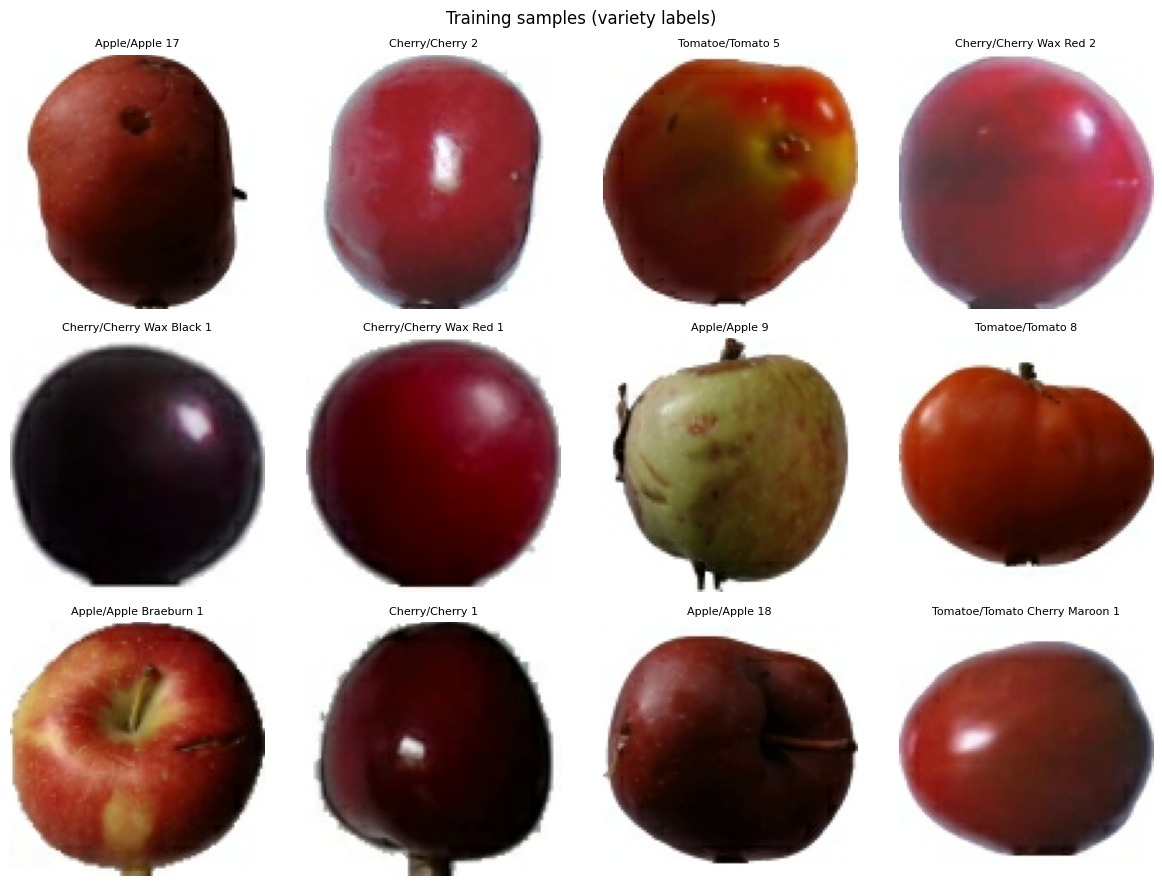

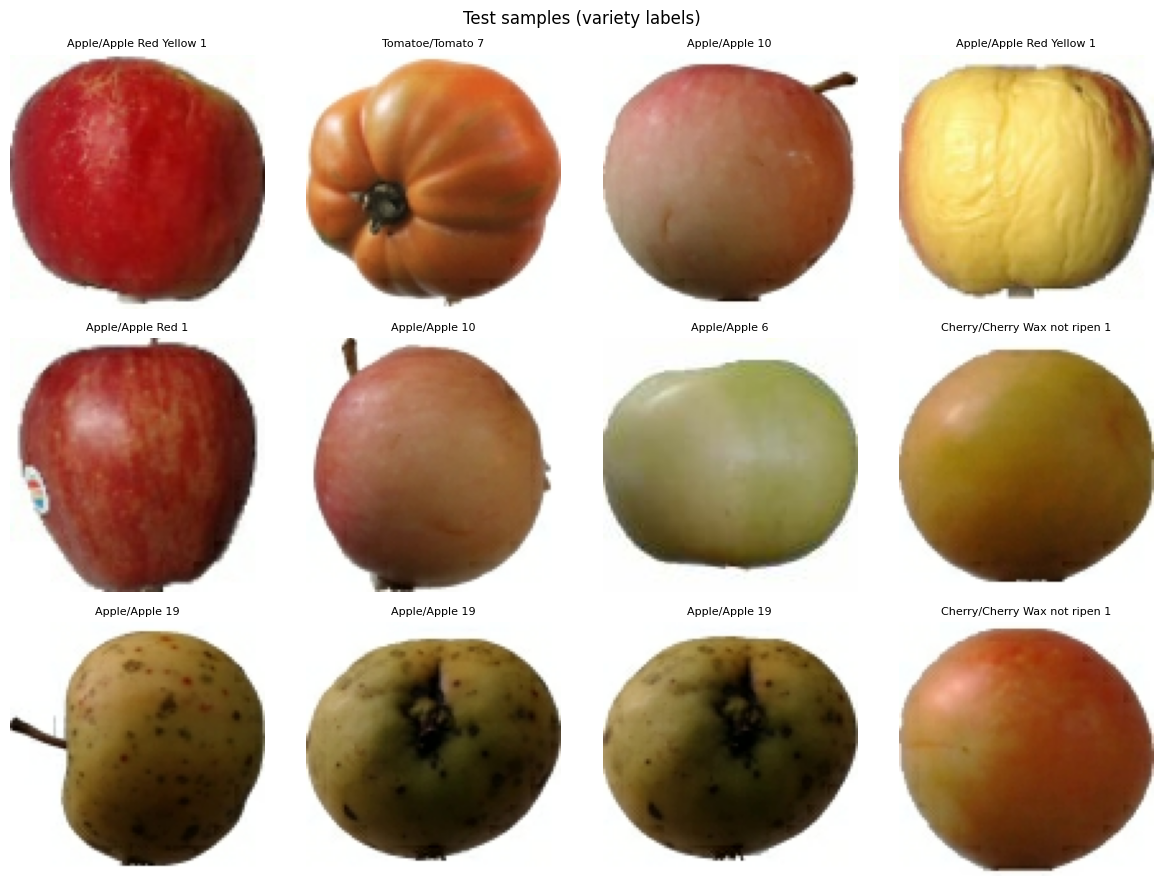

In [8]:
def load_image(path_str):
    img = tf.io.read_file(path_str)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    return img


def show_samples(paths, keys, title, n=12):
    idx = np.random.choice(len(paths), size=min(n, len(paths)), replace=False)
    cols = 4
    rows = int(np.ceil(len(idx) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
    axes = np.array(axes).reshape(-1)
    for ax, i in zip(axes, idx):
        img = load_image(paths[i]).numpy()
        ax.imshow(img)
        ax.set_title(keys[i], fontsize=8)
        ax.axis('off')
    for ax in axes[len(idx):]:
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_samples(train_paths, train_keys, 'Training samples (variety labels)')
show_samples(test_paths, test_keys, 'Test samples (variety labels)')

In [10]:
# Check native resolution (dataset description: 100x100)
sample = load_image(train_paths[0])
print('Sample shape:', tuple(sample.shape))

sizes = []
for i in np.random.choice(len(train_paths), 200, replace=False):
    sh = load_image(train_paths[i]).shape
    sizes.append((int(sh[0]), int(sh[1])))
print('Size distribution (200 random images):', Counter(sizes).most_common(5))

Sample shape: (100, 100, 3)
Size distribution (200 random images): [((100, 100), 200)]


## 4. `tf.data` 파이프라인

In [11]:
def preprocess(path, label, augment=False):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    if augment:
        img = tf.image.random_flip_left_right(img)
        img = tf.image.random_brightness(img, 0.1)
        img = tf.image.random_contrast(img, 0.9, 1.1)
    img = mobilenet_v2.preprocess_input(tf.cast(img, tf.float32))
    label = tf.one_hot(label, NUM_CLASSES)
    return img, label


def make_dataset(paths, labels, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: preprocess(p, y, augment=augment), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


# Train / Validation 분할 (품종 단위 stratify는 경로 셔플로 근사)
n = len(train_paths)
perm = np.random.permutation(n)
n_val = int(n * VALIDATION_SPLIT)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

tr_paths = [train_paths[i] for i in tr_idx]
tr_labels = [train_labels[i] for i in tr_idx]
val_paths = [train_paths[i] for i in val_idx]
val_labels = [train_labels[i] for i in val_idx]

train_ds = make_dataset(tr_paths, tr_labels, shuffle=True, augment=True)
val_ds = make_dataset(val_paths, val_labels, shuffle=False, augment=False)
test_ds = make_dataset(test_paths, test_labels, shuffle=False, augment=False)

print(f'학습: {len(tr_paths):,} / 검증: {len(val_paths):,} / 테스트: {len(test_paths):,}')

학습: 29,580 / 검증: 5,220 / 테스트: 12,233


## 5. Transfer Learning — MobileNetV2

In [ ]:
base_model = mobilenet_v2.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet',
)
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)  # NUM_CLASSES : 64
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d (G  (None, 1280)             0         
 lobalAveragePooling2D)                                          
                                                                 
 dropout (Dropout)           (None, 1280)              0         
                                                                 
 dense (Dense)               (None, 64)                81984     
                                                                 
Total params: 2,339,968
Trainable params: 81,984
Non-trainabl

Epoch 1/15
925/925 [==============================] - 89s 87ms/step - loss: 0.4403 - accuracy: 0.9055 - val_loss: 0.0615 - val_accuracy: 0.9941 - lr: 0.0010
Epoch 2/15
925/925 [==============================] - 55s 60ms/step - loss: 0.0626 - accuracy: 0.9891 - val_loss: 0.0276 - val_accuracy: 0.9964 - lr: 0.0010
Epoch 3/15
925/925 [==============================] - 53s 58ms/step - loss: 0.0360 - accuracy: 0.9931 - val_loss: 0.0194 - val_accuracy: 0.9964 - lr: 0.0010
Epoch 4/15
925/925 [==============================] - 56s 61ms/step - loss: 0.0246 - accuracy: 0.9952 - val_loss: 0.0115 - val_accuracy: 0.9987 - lr: 0.0010
Epoch 5/15
925/925 [==============================] - 55s 60ms/step - loss: 0.0203 - accuracy: 0.9949 - val_loss: 0.0124 - val_accuracy: 0.9969 - lr: 0.0010
Epoch 6/15
925/925 [==============================] - 55s 60ms/step - loss: 0.0169 - accuracy: 0.9955 - val_loss: 0.0089 - val_accuracy: 0.9977 - lr: 0.0010
Epoch 7/15
925/925 [==============================] - 55s 

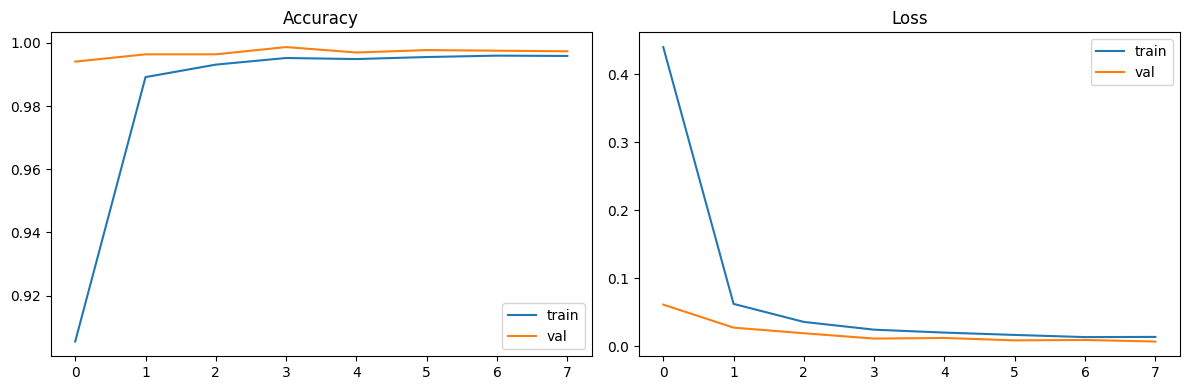

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=4, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
    ),
]

# 학습 시간 : RTX 3060 약 8분 소요 (8 Epoch에서 학습 중단)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()
plt.tight_layout()
plt.show()

In [ ]:
# 상위 블록 미세조정 (Fine-tuning)
base_model.trainable = True
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

fine_tune_epochs = 10
initial_epochs = len(history.history['loss'])

# 학습 시간 : RTX 3060 약 10분 소요 (16 Epoch에서 학습 중단)
history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs + fine_tune_epochs,
    initial_epoch=initial_epochs,
    callbacks=callbacks,
)

Epoch 9/18
925/925 [==============================] - 73s 76ms/step - loss: 0.0178 - accuracy: 0.9943 - val_loss: 0.0020 - val_accuracy: 0.9994 - lr: 1.0000e-05
Epoch 10/18
925/925 [==============================] - 70s 76ms/step - loss: 0.0078 - accuracy: 0.9976 - val_loss: 0.0190 - val_accuracy: 0.9931 - lr: 1.0000e-05
Epoch 11/18
925/925 [==============================] - 71s 77ms/step - loss: 0.0037 - accuracy: 0.9990 - val_loss: 0.0014 - val_accuracy: 0.9996 - lr: 1.0000e-05
Epoch 12/18
925/925 [==============================] - 71s 77ms/step - loss: 0.0040 - accuracy: 0.9989 - val_loss: 3.6158e-04 - val_accuracy: 0.9998 - lr: 1.0000e-05
Epoch 13/18
925/925 [==============================] - 71s 77ms/step - loss: 0.0039 - accuracy: 0.9989 - val_loss: 3.1158e-04 - val_accuracy: 0.9998 - lr: 1.0000e-05
Epoch 14/18
925/925 [==============================] - 70s 76ms/step - loss: 0.0039 - accuracy: 0.9992 - val_loss: 6.8152e-04 - val_accuracy: 0.9998 - lr: 1.0000e-05
Epoch 15/18
925/9

## 6. Test 세트 평가 (학습에 없던 품종)

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy (64-class, unseen varieties): {test_acc:.4f}')

383/383 [==============================] - 28s 72ms/step - loss: 20.0026 - accuracy: 0.0000e+00
Test loss: 20.0026
Test accuracy (64-class, unseen varieties): 0.0000


In [16]:
y_true = np.array(test_labels)
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# Test에만 있는 품종 vs Train에만 있는 품종 구분
test_only_idx = {class_to_idx[k] for k in set(test_keys) - set(train_keys)}
train_only_idx = {class_to_idx[k] for k in set(train_keys) - set(test_keys)}

mask_test_varieties = np.isin(y_true, list(test_only_idx))
acc_unseen = (y_pred[mask_test_varieties] == y_true[mask_test_varieties]).mean()
print(f'Test 전용 품종({len(test_only_idx)}종) subset accuracy: {acc_unseen:.4f}')

from sklearn.metrics import classification_report, confusion_matrix

target_names = [idx_to_class[i] for i in sorted(test_only_idx)]
labels_sorted = sorted(test_only_idx)
print('\nClassification report (Test 품종만):')
print(classification_report(
    y_true, y_pred, labels=labels_sorted, target_names=target_names, zero_division=0
))

383/383 [==============================] - 15s 38ms/step
Test 전용 품종(16종) subset accuracy: 0.0000

Classification report (Test 품종만):
                               precision    recall  f1-score   support

               Apple/Apple 10       0.00      0.00      0.00     930.0
               Apple/Apple 19       0.00      0.00      0.00     970.0
                Apple/Apple 6       0.00      0.00      0.00     630.0
         Apple/Apple Golden 1       0.00      0.00      0.00     640.0
   Apple/Apple Granny Smith 1       0.00      0.00      0.00     656.0
            Apple/Apple Red 1       0.00      0.00      0.00     656.0
     Apple/Apple Red Yellow 1       0.00      0.00      0.00     656.0
              Cherry/Cherry 3       0.00      0.00      0.00     930.0
      Cherry/Cherry Rainier 1       0.00      0.00      0.00     984.0
      Cherry/Cherry Wax Red 3       0.00      0.00      0.00     604.0
Cherry/Cherry Wax not ripen 1       0.00      0.00      0.00     900.0
             To

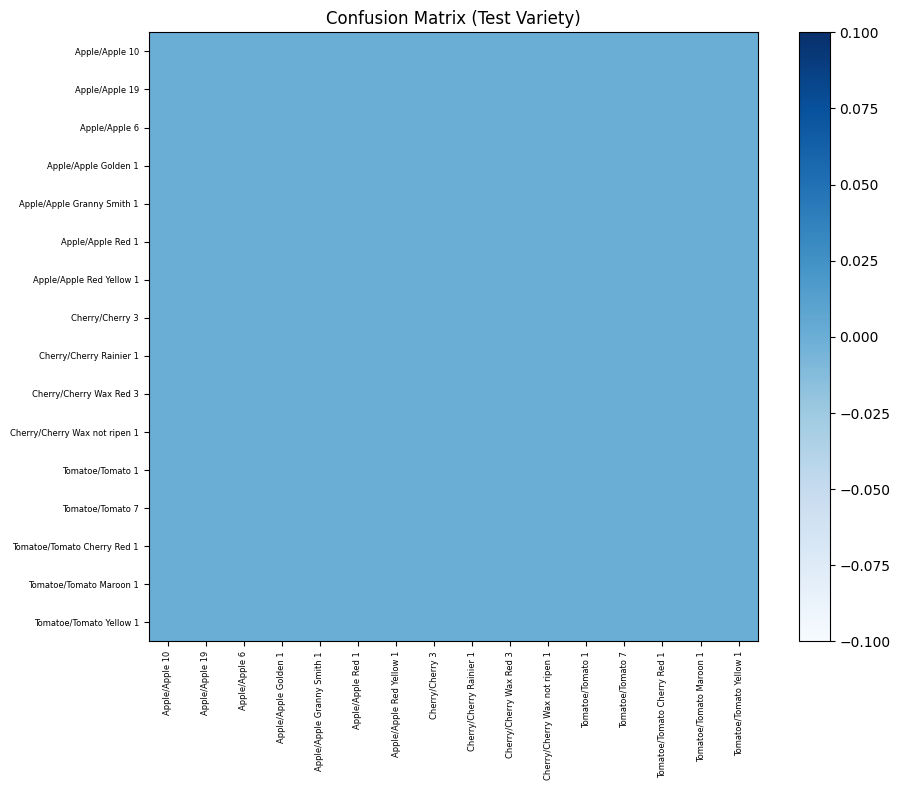

In [21]:
cm = confusion_matrix(y_true, y_pred, labels=labels_sorted)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_title('Confusion Matrix (Test Variety)')
ax.set_xticks(range(len(labels_sorted)))
ax.set_yticks(range(len(labels_sorted)))
ax.set_xticklabels([idx_to_class[i] for i in labels_sorted], rotation=90, fontsize=6)
ax.set_yticklabels([idx_to_class[i] for i in labels_sorted], fontsize=6)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

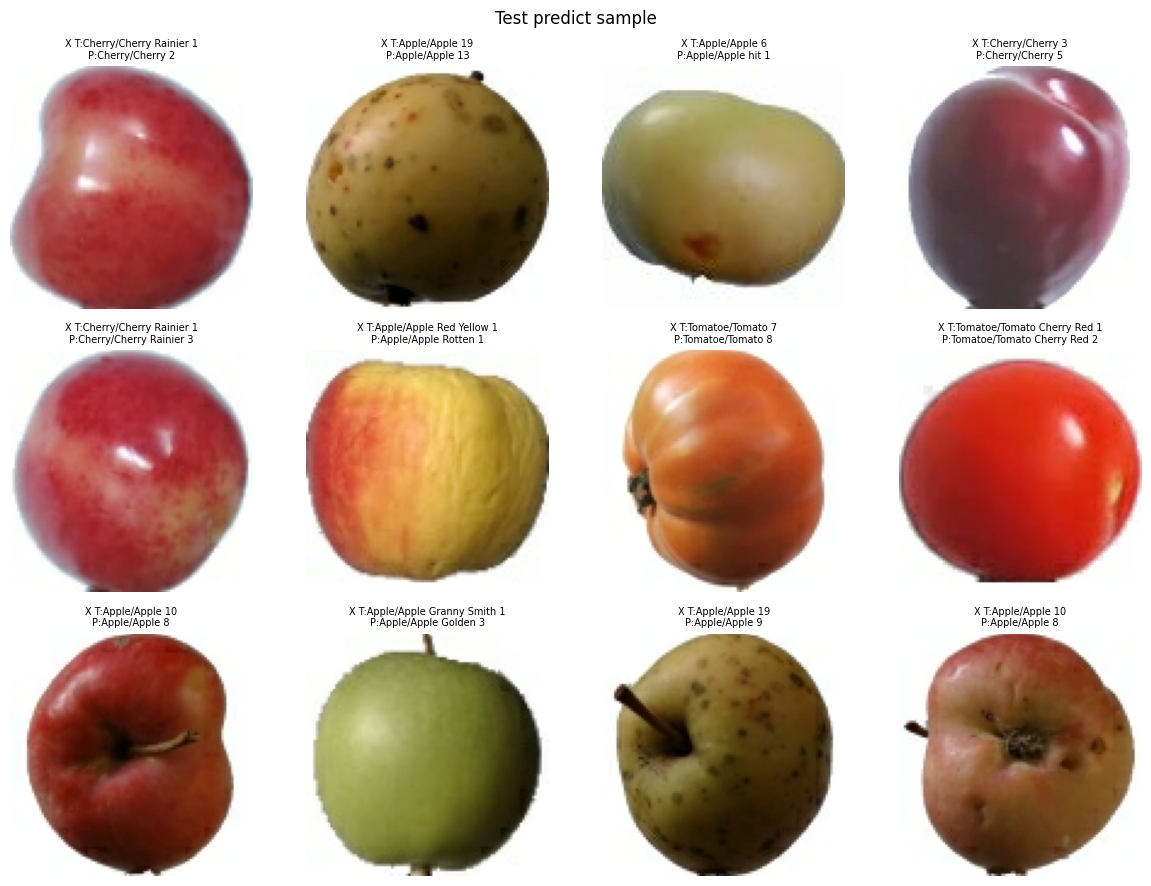

In [22]:
# 예측 샘플 시각화
n_show = 12
idx = np.random.choice(len(test_paths), n_show, replace=False)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))
for ax, i in zip(axes.ravel(), idx):
    img = load_image(test_paths[i]).numpy()
    ax.imshow(img)
    true_name = test_keys[i]
    pred_name = idx_to_class[int(y_pred[i])]
    ok = 'O' if y_pred[i] == y_true[i] else 'X'
    ax.set_title(f'{ok} T:{true_name}\nP:{pred_name}', fontsize=7)
    ax.axis('off')
plt.suptitle('Test predict sample')
plt.tight_layout()
plt.show()

## 7. 모델 및 라벨 맵 저장

In [20]:
save_dir = ROOT / 'saved_models' / 'fruits360_3body_varieties'
save_dir.mkdir(parents=True, exist_ok=True)

model.save(save_dir / 'mobilenetv2_varieties.h5')
with open(save_dir / 'class_to_idx.json', 'w', encoding='utf-8') as f:
    json.dump(class_to_idx, f, ensure_ascii=False, indent=2)

print('저장 완료:', save_dir)

저장 완료: C:\MyCursorLab\04_딥러닝_CNN\saved_models\fruits360_3body_varieties
